# Llama-3.2-3B IT Ticket Classifier — v3 Single-Run## Goal: Fair Comparison vs V2 (Staged Training)This notebook is **identical to V2** except for one change:| Aspect | V2 (Staged) | V3 (Single-Run) ||---|---|---|| Training strategy | 7 stages × 3,388 samples | **1 run × 23,720 samples** || Early stopping | per-stage (patience=2) | **global (patience=2)** || Everything else | — | **IDENTICAL** |### Scientific Question> Does staged training sacrifice quality for speed, or is the final F1 equivalent?### Everything Else IS Identical to V2- Model: `unsloth/Llama-3.2-3B-bnb-4bit`- LoRA: r=16, α=32 (=2r), dropout=0.05, rsLoRA, all 7 layers- Optimizer: AdamW8bit, lr=2e-4, weight_decay=0.01- Scheduler: Linear no warmup- max_grad_norm=1.0, effective batch=32 (2 × 16 accum)- Max epochs=3, patience=2- Head: Single Linear (3072→10) in float32- Pooling: Last non-padding token- Dynamic padding (right)- Split: random_state=42, stratify=Department (train=23,720 / val=2,965 / test=2,965)### Total Optimizer Steps (nearly identical to V2)- **V2:** 7 stages × 3 epochs × ~106 updates = ~2,226 updates- **V3:** 3 epochs × ~741 updates = ~2,223 updates ✅### Checkpoint Path (separate from V2)`/content/drive/MyDrive/llama32-ticket-cls-v3-singlerun`

## Cell 1 — Install Libraries

In [ ]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

!pip install -q unsloth
!pip install -q --no-deps trl peft accelerate bitsandbytes
!pip install -q "transformers>=4.45.0,<5.0.0" "datasets>=2.18.0"
!pip install -q scikit-learn matplotlib seaborn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 121.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.2/421.2 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22

## Cell 2 — Imports

In [ ]:
import os, gc, json, math, random, shutil, torch, torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import bitsandbytes as bnb

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from transformers import (
    DataCollatorWithPadding, get_linear_schedule_with_warmup
)
from peft import PeftModel
from unsloth import FastLanguageModel
from google.colab import drive

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('VRAM:', f'{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB' if torch.cuda.is_available() else 'N/A')

/tmp/ipykernel_16172/2018230833.py:18: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU: Tesla T4
VRAM: 15.6 GB


## Cell 3 — Configuration**Everything is IDENTICAL to V2 except:**- `CHECKPOINT_BASE` (new separate path)- No `STAGE_SIZE` / `NUM_STAGES` (single-run uses full training set)- Only `LoRA_r16` config (matches the already-tested V2 config)

In [ ]:
# ══════════════════════════════════════════════════
# PATHS
# ══════════════════════════════════════════════════
DATA_PATH       = '/content/drive/MyDrive/IT Support Ticket Data.csv'
CHECKPOINT_BASE = '/content/drive/MyDrive/llama32-ticket-cls-v3-singlerun-r8'

# ══════════════════════════════════════════════════
# MODEL (same as V2)
# ══════════════════════════════════════════════════
MODEL_NAME  = 'unsloth/Llama-3.2-3B-bnb-4bit'
MAX_SEQ_LEN = 256

# ══════════════════════════════════════════════════
# DATA SPLIT (same as V2 / Classical ML)
# ══════════════════════════════════════════════════
RANDOM_STATE = 42
TEST_SIZE    = 0.2
VAL_SIZE     = 0.5

# ══════════════════════════════════════════════════
# TRAINING HYPERPARAMETERS (identical to V2)
# ══════════════════════════════════════════════════
BATCH_SIZE              = 2
EVAL_BATCH_SIZE         = 8
GRAD_ACCUM              = 16    # effective batch = 32
MAX_EPOCHS              = 3
EARLY_STOPPING_PATIENCE = 2     # now GLOBAL (no stages)
WEIGHT_DECAY            = 0.01
MAX_GRAD_NORM           = 1.0

# ══════════════════════════════════════════════════
# LORA TARGET MODULES (identical to V2)
# ══════════════════════════════════════════════════
LORA_TARGET_MODULES = [
    'q_proj', 'k_proj', 'v_proj', 'o_proj',
    'gate_proj', 'up_proj', 'down_proj',
]

# ══════════════════════════════════════════════════
# LORA CONFIG — ONLY LoRA_r16 (match V2 tested config)
# r=16, alpha=32 (=2r), dropout=0.05, lr=2e-4
# ══════════════════════════════════════════════════
LORA_CONFIG = {'name': 'LoRA_r8', 'r': 8, 'alpha': 16, 'lr': 2e-4, 'dropout': 0.05}

# ══════════════════════════════════════════════════
# CLASSES (identical to V2)
# ══════════════════════════════════════════════════
DEPARTMENTS = [
    'Billing and Payments', 'Customer Service', 'General Inquiry',
    'Human Resources', 'IT Support', 'Product Support',
    'Returns and Exchanges', 'Sales and Pre-Sales',
    'Service Outages and Maintenance', 'Technical Support',
]
LABEL2ID = {d: i for i, d in enumerate(DEPARTMENTS)}
ID2LABEL = {i: d for d, i in LABEL2ID.items()}
NUM_CLASSES = len(DEPARTMENTS)

print('✅ Config loaded (V3 Single-Run)')
print(f'   Model       : {MODEL_NAME}')
print(f'   Strategy    : SINGLE-RUN on full training set')
print(f'   LoRA        : r={LORA_CONFIG["r"]} alpha={LORA_CONFIG["alpha"]} '
      f'(={LORA_CONFIG["alpha"]//LORA_CONFIG["r"]}r) '
      f'dropout={LORA_CONFIG["dropout"]} lr={LORA_CONFIG["lr"]}')
print(f'   Eff. batch  : {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}')
print(f'   Max epochs  : {MAX_EPOCHS} | Patience: {EARLY_STOPPING_PATIENCE} (global)')
print(f'   Grad norm   : {MAX_GRAD_NORM}')

✅ Config loaded (V3 Single-Run)
   Model       : unsloth/Llama-3.2-3B-bnb-4bit
   Strategy    : SINGLE-RUN on full training set
   LoRA        : r=8 alpha=16 (=2r) dropout=0.05 lr=0.0002
   Eff. batch  : 2 × 16 = 32
   Max epochs  : 3 | Patience: 2 (global)
   Grad norm   : 1.0


## Cell 4 — Mount Drive & Load Data

In [ ]:
drive.mount('/content/drive')
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

df = pd.read_csv(DATA_PATH, index_col=0)
df = df.dropna(subset=['Body']).reset_index(drop=True)
df = df[['Body', 'Department']]
df = df[df['Department'].isin(DEPARTMENTS)].reset_index(drop=True)

print(f'Total samples: {len(df)}')
print('Department distribution:')
print(df['Department'].value_counts())

Mounted at /content/drive
Total samples: 29650
Department distribution:
Department
Technical Support                  8617
Product Support                    5538
Customer Service                   4482
IT Support                         3500
Billing and Payments               3017
Returns and Exchanges              1467
Service Outages and Maintenance    1157
Sales and Pre-Sales                 885
Human Resources                     568
General Inquiry                     419
Name: count, dtype: int64


## Cell 5 — Data Split (No Stages)**Critical:** Same `random_state=42` and `stratify=Department` as V2 → the train/val/test splits are byte-identical. The ONLY difference is we do NOT slice `train_df` into 7 stages.

In [ ]:
# Same split as V2 / Classical ML for fair comparison
train_df, temp_df = train_test_split(
    df, test_size=TEST_SIZE,
    stratify=df['Department'], random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=VAL_SIZE,
    stratify=temp_df['Department'], random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):>6}  (100% — single run)')
print(f'Val   : {len(val_df):>6}')
print(f'Test  : {len(test_df):>6}')
print()
print('Train class distribution:')
print(train_df['Department'].value_counts())

Train :  23720  (100% — single run)
Val   :   2965
Test  :   2965

Train class distribution:
Department
Technical Support                  6894
Product Support                    4430
Customer Service                   3586
IT Support                         2800
Billing and Payments               2413
Returns and Exchanges              1174
Service Outages and Maintenance     926
Sales and Pre-Sales                 708
Human Resources                     454
General Inquiry                     335
Name: count, dtype: int64


## Cell 6 — Tokenizer + Dataset + Dynamic Padding (identical to V2)

In [ ]:
# Load tokenizer once
_, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LEN,
    dtype=None,
    load_in_4bit=True,
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'   # paper Table 1 + V2


class TicketDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.texts     = dataframe['Body'].astype(str).tolist()
        self.labels    = [LABEL2ID[d] for d in dataframe['Department'].tolist()]
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         self.labels[idx],
        }


# Dynamic padding — pad only to longest in each batch (paper Table 1)
base_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding='longest')


class TicketCollator:
    def __init__(self, collator):
        self.collator = collator
    def __call__(self, features):
        labels = [f.pop('labels') for f in features]
        batch  = self.collator(features)
        batch['labels'] = torch.tensor(labels, dtype=torch.long)
        return batch


collator = TicketCollator(base_collator)

# Full-training loader (no staging)
train_loader = DataLoader(
    TicketDataset(train_df, tokenizer, MAX_SEQ_LEN),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator,
)
val_loader = DataLoader(
    TicketDataset(val_df, tokenizer, MAX_SEQ_LEN),
    batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collator,
)
test_loader = DataLoader(
    TicketDataset(test_df, tokenizer, MAX_SEQ_LEN),
    batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collator,
)

print('✅ Tokenizer + Dynamic padding ready')
print(f'   Train batches : {len(train_loader)}  (batch_size={BATCH_SIZE})')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')
print(f'   Optimizer updates per epoch: {math.ceil(len(train_loader) / GRAD_ACCUM)}')

==((====))==  Unsloth 2026.4.6: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

✅ Tokenizer + Dynamic padding ready
   Train batches : 11860  (batch_size=2)
   Val batches   : 371
   Test batches  : 371
   Optimizer updates per epoch: 742


## Cell 7 — Model: Llama-3.2-3B + rsLoRA + Single Linear Head (identical to V2)

In [ ]:
class LlamaTicketClassifier(nn.Module):
    """
    Embedding-based classification — IDENTICAL to V2.

    - Last non-padding token pooling
    - Single Linear head: hidden_size → num_classes (paper Table 1)
    - head in float32 to avoid NaN loss with 4-bit backbone
    - rsLoRA enabled (use_rslora=True)
    - All 7 linear layers targeted
    """

    def __init__(self, model_name, num_classes, lora_cfg,
                 adapter_path=None, is_trainable=True):
        super().__init__()
        self.lora_cfg = lora_cfg

        base_model, _ = FastLanguageModel.from_pretrained(
            model_name=model_name,
            max_seq_length=MAX_SEQ_LEN,
            dtype=None,
            load_in_4bit=True,
        )

        if adapter_path is None:
            self.backbone = FastLanguageModel.get_peft_model(
                base_model,
                r                          = lora_cfg['r'],
                lora_alpha                 = lora_cfg['alpha'],
                target_modules             = LORA_TARGET_MODULES,
                lora_dropout               = lora_cfg['dropout'],
                bias                       = 'none',
                use_rslora                 = True,
                use_gradient_checkpointing = 'unsloth',
                random_state               = RANDOM_STATE,
            )
            print('Loaded fresh rsLoRA adapters for training.')
        else:
            self.backbone = PeftModel.from_pretrained(
                base_model, adapter_path, is_trainable=is_trainable,
            )
            print(f'Loaded adapters from: {adapter_path}')

        self.backbone.print_trainable_parameters()

        hidden_size = self.backbone.config.hidden_size  # 3072 for Llama-3.2-3B

        # Single Linear head in float32 (paper Table 1)
        self.classifier = nn.Linear(hidden_size, num_classes).float()
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)
        self.classifier = self.classifier.to(device=self.backbone.device)

        self.loss_fn = nn.CrossEntropyLoss()

        print()
        print('✅ LlamaTicketClassifier ready')
        print(f'   Hidden size : {hidden_size}')
        print(f'   Head        : {hidden_size} → {num_classes}  (single linear)')
        print(f'   rsLoRA      : enabled | alpha={lora_cfg["alpha"]} = {lora_cfg["alpha"]//lora_cfg["r"]}r')
        print(f'   Pooling     : last non-padding token')
        print(f'   Dropout     : {lora_cfg["dropout"]} (LoRA)')

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        last_hidden  = outputs.hidden_states[-1]
        seq_lengths  = attention_mask.sum(dim=1) - 1
        batch_size   = input_ids.shape[0]
        pooled = last_hidden[
            torch.arange(batch_size, device=input_ids.device),
            seq_lengths,
        ].float()

        logits = self.classifier(pooled)
        loss   = self.loss_fn(logits, labels) if labels is not None else None
        return {'loss': loss, 'logits': logits}


def build_model(lora_cfg, adapter_path=None, is_trainable=True):
    return LlamaTicketClassifier(
        model_name   = MODEL_NAME,
        num_classes  = NUM_CLASSES,
        lora_cfg     = lora_cfg,
        adapter_path = adapter_path,
        is_trainable = is_trainable,
    )


print('✅ Model class defined')

✅ Model class defined


## Cell 8 — Evaluation Function (identical to V2)

In [ ]:
def evaluate(model, loader, split_name='Val', show_plots=True, save_dir=None):
    model.eval()
    device     = next(model.parameters()).device
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            out = model(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device),
            )
            all_preds.extend(out['logits'].argmax(dim=-1).cpu().numpy())
            all_labels.extend(batch['labels'].numpy())

    acc    = accuracy_score(all_labels, all_preds)
    f1m    = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    f1w    = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1_pc  = f1_score(all_labels, all_preds, average=None,       zero_division=0)
    cm     = confusion_matrix(all_labels, all_preds)
    report = classification_report(
        all_labels, all_preds, target_names=DEPARTMENTS,
        zero_division=0, output_dict=True
    )

    print('=' * 65)
    print(f'  {split_name}')
    print('=' * 65)
    print(f'  Accuracy    : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  F1 Macro    : {f1m:.4f}')
    print(f'  F1 Weighted : {f1w:.4f}')
    print()
    print(classification_report(
        all_labels, all_preds, target_names=DEPARTMENTS, zero_division=0
    ))

    if show_plots:
        fig = plt.figure(figsize=(18, 7))
        gs  = gridspec.GridSpec(1, 2, width_ratios=[1.8, 1])

        ax1 = fig.add_subplot(gs[0])
        short = [d[:18] for d in DEPARTMENTS]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=short, yticklabels=short, ax=ax1)
        ax1.set_title(f'Confusion Matrix — {split_name}', fontsize=13)
        ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')
        plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        plt.setp(ax1.get_yticklabels(), rotation=0,  fontsize=8)

        ax2 = fig.add_subplot(gs[1])
        sns.barplot(x=f1_pc, y=short, ax=ax2, palette='viridis')
        ax2.set_xlim(0, 1); ax2.set_xlabel('F1-score')
        ax2.set_title('F1 per Class')
        for i, v in enumerate(f1_pc):
            ax2.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)

        plt.tight_layout()
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            fp = os.path.join(save_dir, f'{split_name.replace(" ", "_")}.png')
            plt.savefig(fp, dpi=120, bbox_inches='tight')
            print(f'  📊 Saved: {fp}')
        plt.show()
        plt.close(fig)

    return {
        'accuracy': acc, 'f1_macro': f1m, 'f1_weighted': f1w,
        'f1_per_class': f1_pc.tolist(),
        'confusion_matrix': cm.tolist(),
        'classification_report': report,
    }


print('✅ Evaluate function defined')

✅ Evaluate function defined


## Cell 9 — Checkpoint Functions (adapted from V2)Naming convention for V3 (no stages, just epochs):- `epoch1`, `epoch2`, `epoch3` — per-epoch checkpoints- `LAST` — most recent epoch (for resume)- `BEST` — highest val F1-macro across all epochs

In [ ]:
def checkpoint_dir(lora_name, tag):
    return os.path.join(CHECKPOINT_BASE, lora_name, tag)

def adapter_dir(lora_name, tag):
    return os.path.join(checkpoint_dir(lora_name, tag), 'lora_adapters')


def save_checkpoint(model, optimizer, scheduler, epoch, lora_name,
                    metrics, best_val_f1, patience_counter, train_history,
                    tag=None, is_best=False):
    tag      = tag or f'epoch{epoch}'
    ckpt_dir = checkpoint_dir(lora_name, tag)
    os.makedirs(ckpt_dir, exist_ok=True)

    model.backbone.save_pretrained(adapter_dir(lora_name, tag))
    torch.save(model.classifier.state_dict(),
               os.path.join(ckpt_dir, 'classifier_head.pt'))

    state = {
        'epoch': epoch, 'lora_name': lora_name,
        'best_val_f1': best_val_f1,
        'patience_counter': patience_counter, 'metrics': metrics,
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict() if scheduler else None,
        'train_history': train_history, 'is_best': is_best, 'tag': tag,
    }
    torch.save(state, os.path.join(ckpt_dir, 'training_state.pt'))

    mj = {
        'epoch': epoch, 'lora_config': lora_name,
        'tag': tag, 'is_best': is_best,
        'accuracy':    round(metrics['accuracy'],    6),
        'f1_macro':    round(metrics['f1_macro'],    6),
        'f1_weighted': round(metrics['f1_weighted'], 6),
        'train_loss':  round(metrics.get('train_loss', 0.0), 6),
        'train_acc':   round(metrics.get('train_acc',  0.0), 6),
        'f1_per_class': {DEPARTMENTS[i]: round(v, 4)
                         for i, v in enumerate(metrics['f1_per_class'])},
    }
    with open(os.path.join(ckpt_dir, 'metrics.json'), 'w') as f:
        json.dump(mj, f, indent=2)

    label = '🏆 BEST' if is_best else '💾'
    print(f'  {label} Checkpoint → {ckpt_dir}')
    print(f'     acc={metrics["accuracy"]:.4f} | F1-macro={metrics["f1_macro"]:.4f}')


def load_checkpoint_state(optimizer, scheduler, lora_name, tag='LAST'):
    ckpt_dir = checkpoint_dir(lora_name, tag)
    if not os.path.exists(ckpt_dir):
        print(f'  ⚠️  Not found: {ckpt_dir}')
        return None
    state = torch.load(os.path.join(ckpt_dir, 'training_state.pt'),
                       map_location='cpu')
    optimizer.load_state_dict(state['optimizer'])
    if scheduler and state.get('scheduler'):
        scheduler.load_state_dict(state['scheduler'])
    print(f'  ✅ Loaded state: ep={state["epoch"]} '
          f'best_f1={state["best_val_f1"]:.4f}')
    return state


def load_classifier_head(model, lora_name, tag='BEST'):
    ckpt_dir = checkpoint_dir(lora_name, tag)
    if not os.path.exists(ckpt_dir):
        print(f'⚠️  Checkpoint not found: {lora_name} @ {tag}')
        return False
    model.classifier.load_state_dict(
        torch.load(os.path.join(ckpt_dir, 'classifier_head.pt'),
                   map_location=model.classifier.weight.device)
    )
    print(f'✅ Loaded classifier head: {ckpt_dir}')
    return True


def list_checkpoints():
    if not os.path.exists(CHECKPOINT_BASE):
        print('No checkpoints directory yet.')
        return
    for lora_name in sorted(os.listdir(CHECKPOINT_BASE)):
        d = os.path.join(CHECKPOINT_BASE, lora_name)
        if not os.path.isdir(d):
            continue
        print(f'\n📁 {lora_name}')
        for tag in sorted(os.listdir(d)):
            tp = os.path.join(d, tag)
            if not os.path.isdir(tp):
                continue
            mf = os.path.join(tp, 'metrics.json')
            if os.path.exists(mf):
                with open(mf) as f:
                    m = json.load(f)
                flag = ' 🏆' if m.get('is_best') else ''
                print(f'   • {tag:<12} ep={m.get("epoch","?")} '
                      f'F1={m.get("f1_macro",0):.4f} '
                      f'acc={m.get("accuracy",0):.4f}{flag}')
            else:
                print(f'   • {tag}')


print('✅ Checkpoint functions defined')

✅ Checkpoint functions defined


## Cell 10 — Training Loop (Single-Run)### Key differences from V2 training loop:1. **No stage loop** — one continuous training over the full dataset2. **Global early stopping** — patience=2 across epochs (not per-stage)3. **Checkpoint naming:** `epoch1`, `epoch2`, `epoch3` (no stage prefix)4. **Scheduler total_steps** = `ceil(len(train_loader) / GRAD_ACCUM) × MAX_EPOCHS`### Identical to V2:- Forward/backward/gradient clipping logic- Optimizer step triggered on `step % GRAD_ACCUM == 0` OR last step- Evaluate on val set at end of each epoch- BEST / LAST tags saved alongside per-epoch tags

In [ ]:
def build_global_scheduler(optimizer):
    """Linear schedule, no warmup (paper Table 1). Same as V2 but total_steps
    is based on full-training single-run, not stages."""
    steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM)
    total_steps     = max(steps_per_epoch * MAX_EPOCHS, 1)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps,
    )
    print(f'  Scheduler: {total_steps} total steps '
          f'({steps_per_epoch} per epoch × {MAX_EPOCHS} epochs)')
    return scheduler


def train_single_run(model, optimizer, scheduler, lora_name,
                     start_epoch=1, global_best_f1=0.0,
                     patience_counter=0, train_history=None):
    """
    Single-run training over the full training set.

    Logic mirrors V2 train_one_stage but without the stage loop.
    Early stopping is GLOBAL (across epochs), patience=2.
    """
    device        = next(model.parameters()).device
    train_history = train_history or []

    print()
    print('=' * 72)
    print(f'  SINGLE-RUN TRAINING | {lora_name}')
    print(f'  Train samples: {len(train_df)} | Batches: {len(train_loader)} | '
          f'Max epochs: {MAX_EPOCHS} | Patience: {EARLY_STOPPING_PATIENCE} (global)')
    print(f'  Starting at epoch {start_epoch} | best_f1 so far: {global_best_f1:.4f}')
    print('=' * 72)

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        correct = total = 0
        optimizer.zero_grad()

        for step, batch in enumerate(train_loader, start=1):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            out  = model(input_ids=input_ids,
                         attention_mask=attention_mask, labels=labels)
            loss = out['loss'] / GRAD_ACCUM
            loss.backward()

            if (step % GRAD_ACCUM == 0) or (step == len(train_loader)):
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad],
                    MAX_GRAD_NORM,
                )
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            total_loss += out['loss'].item()
            preds   = out['logits'].argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            # Log every 500 steps (bigger run than V2 stage)
            if step % 500 == 0 or step == len(train_loader):
                cur_lr = scheduler.get_last_lr()[0]
                print(f'   Ep{epoch} | Step {step:>5}/{len(train_loader)} | '
                      f'Loss:{total_loss/step:.4f} | Acc:{correct/total:.4f} | '
                      f'LR:{cur_lr:.2e}')

        train_acc = correct / total
        avg_loss  = total_loss / len(train_loader)
        print(f'\n  ── Ep{epoch} done | Loss={avg_loss:.4f} | '
              f'TrainAcc={train_acc:.4f}')

        # Validate
        val_m = evaluate(model, val_loader,
                         split_name=f'Val Ep{epoch}',
                         show_plots=False)
        val_m['train_acc']  = train_acc
        val_m['train_loss'] = avg_loss

        train_history.append({
            'epoch': epoch,
            'train_loss': avg_loss, 'train_acc': train_acc,
            'val_accuracy': val_m['accuracy'],
            'val_f1_macro': val_m['f1_macro'],
            'val_f1_weighted': val_m['f1_weighted'],
        })

        # Save per-epoch + LAST
        for tag in [f'epoch{epoch}', 'LAST']:
            save_checkpoint(model, optimizer, scheduler,
                            epoch, lora_name,
                            val_m, global_best_f1,
                            patience_counter, train_history,
                            tag=tag, is_best=False)

        # Update BEST
        if val_m['f1_macro'] > global_best_f1:
            global_best_f1   = val_m['f1_macro']
            patience_counter = 0
            save_checkpoint(model, optimizer, scheduler,
                            epoch, lora_name,
                            val_m, global_best_f1,
                            patience_counter, train_history,
                            tag='BEST', is_best=True)
            print(f'  🏆 New BEST F1: {global_best_f1:.4f}')
        else:
            patience_counter += 1
            print(f'  ⏸  No improvement. '
                  f'patience={patience_counter}/{EARLY_STOPPING_PATIENCE}')
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f'  ⛔ Early stop at epoch {epoch}')
                break

    # Final eval plot on val
    evaluate(model, val_loader,
             split_name='Final Val (Single-Run)',
             show_plots=True,
             save_dir=os.path.join(CHECKPOINT_BASE, lora_name))

    return global_best_f1, train_history, patience_counter


print('✅ Single-run training loop defined')

✅ Single-run training loop defined


## Cell 11 — Main Training (Single-Run LoRA_r16)**Expected runtime on T4:** ~8–12 hours for 3 epochs on 23,720 samples.### Colab Free Protection- Keep the tab active (browser extension or periodic interaction)- If disconnected, run Cells 1–10 again then **Cell 12 (Resume)** to continue


########################################################################
  V3 SINGLE-RUN EXPERIMENT: LoRA_r16
  r=16 | alpha=32 (=2r) | lr=0.0002 | dropout=0.05
  Full training set: 23720 samples (no staging)
########################################################################
==((====))==  Unsloth 2026.4.6: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.6 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Loaded fresh rsLoRA adapters for training.
trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511

✅ LlamaTicketClassifier ready
   Hidden size : 3072
   Head        : 3072 → 10  (single linear)
   rsLoRA      : enabled | alpha=32 = 2r
   Pooling     : last non-padding token
   Dropout     : 0.05 (LoRA)
  Scheduler: 2226 total steps (742 per epoch × 3 epochs)

  SINGLE-RUN TRAINING | LoRA_r16
  Train samples: 23720 | Batches: 11860 | Max epochs: 3 | Patience: 2 (global)
  Starting at epoch 1 | best_f1 so far: 0.0000
   Ep1 | Step   500/11860 | Loss:2.4324 | Acc:0.2410 | LR:1.97e-04
   Ep1 | Step  1000/11860 | Loss:2.1674 | Acc:0.2920 | LR:1.94e-04
   Ep1 | Step  1500/11860 | Loss:2.0544 | Acc:0.3080 | LR:1.92e-04
   Ep1 | Step  2000/11860 | Loss:2.0024 | Acc:0.3150 | LR:1.89e-04
   Ep1 | Step  2500/11860 | Loss:1.9476 | Acc:0.3242 | LR:1.86e-04
   Ep1 | Step  3000/11860 | Loss:1.9070 | Acc:0.3338 | LR:1.83e-04
   Ep1 | Step  3500/11860 | Loss:1.8832 | Acc:0.337

/tmp/ipykernel_2708/2135555504.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=f1_pc, y=short, ax=ax2, palette='viridis')


  📊 Saved: /content/drive/MyDrive/llama32-ticket-cls-v3-singlerun/LoRA_r16/Final_Val_(Single-Run).png


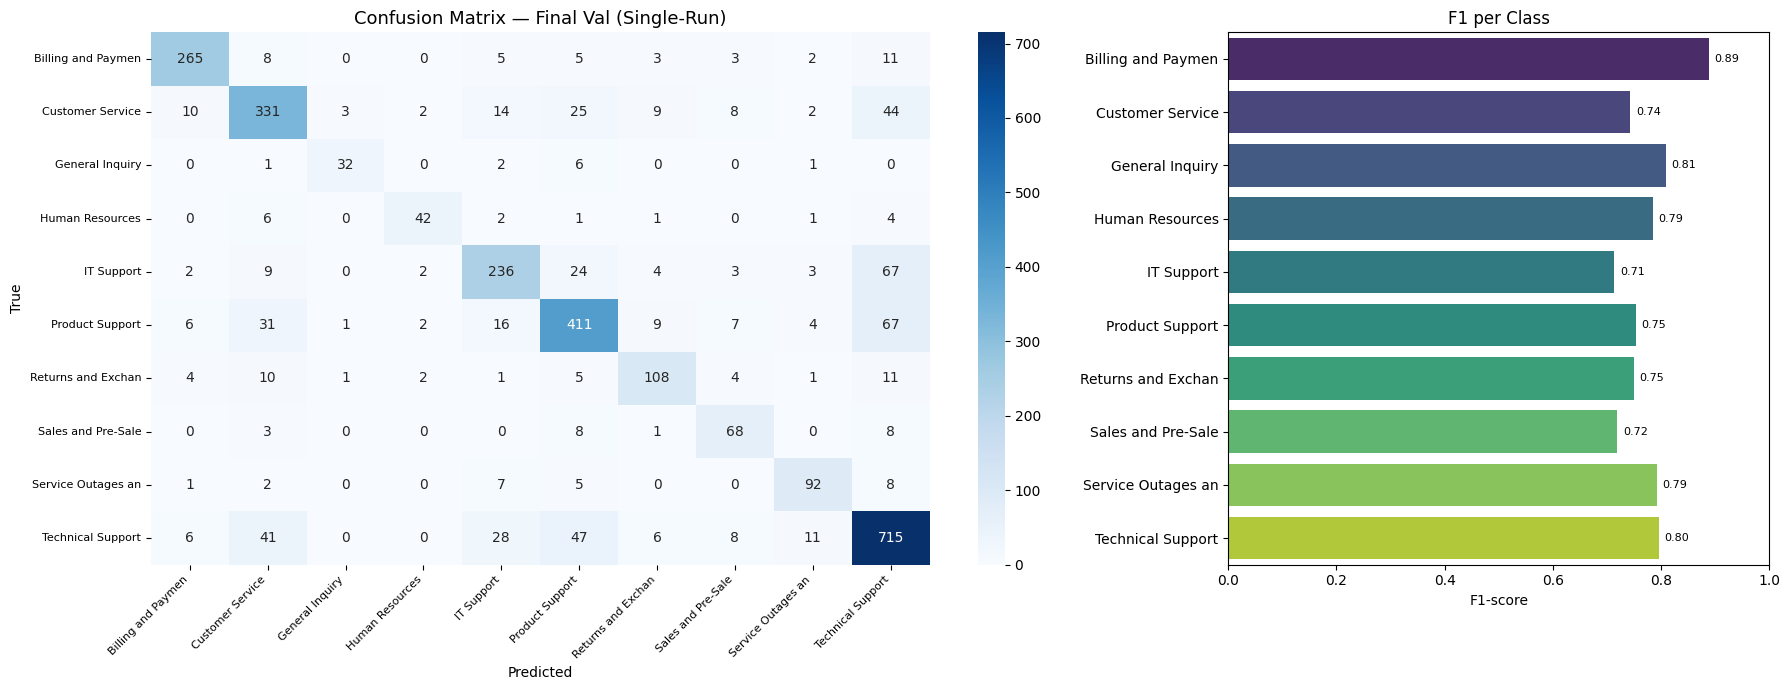


  TRAINING COMPLETE — LoRA_r16 (V3 Single-Run)
  Best Val F1-Macro : 0.7754
  Epochs completed  : 3/3


In [ ]:
# ══════════════════════════════════════════════════
# Fresh start: LoRA_r16 single-run
# ══════════════════════════════════════════════════
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

cfg       = LORA_CONFIG
lora_name = cfg['name']

print()
print('#' * 72)
print(f'  V3 SINGLE-RUN EXPERIMENT: {lora_name}')
print(f'  r={cfg["r"]} | alpha={cfg["alpha"]} (={cfg["alpha"]//cfg["r"]}r) | '
      f'lr={cfg["lr"]} | dropout={cfg["dropout"]}')
print(f'  Full training set: {len(train_df)} samples (no staging)')
print('#' * 72)

model     = build_model(cfg)
trainable = [p for p in model.parameters() if p.requires_grad]

# AdamW8bit — identical to V2
optimizer = bnb.optim.AdamW8bit(
    trainable,
    lr           = cfg['lr'],
    weight_decay = WEIGHT_DECAY,
)

# Global linear scheduler (no warmup) — paper Table 1
scheduler = build_global_scheduler(optimizer)

# Train
best_val_f1, train_history, _ = train_single_run(
    model, optimizer, scheduler, lora_name,
    start_epoch=1, global_best_f1=0.0,
)

# Persist history
summary_dir = os.path.join(CHECKPOINT_BASE, lora_name)
os.makedirs(summary_dir, exist_ok=True)
with open(os.path.join(summary_dir, 'training_history.json'), 'w') as f:
    json.dump(train_history, f, indent=2, default=str)

summary = {
    'config':            lora_name,
    'strategy':          'single_run_full_dataset',
    'r':                 cfg['r'],
    'alpha':             cfg['alpha'],
    'train_samples':     len(train_df),
    'max_epochs':        MAX_EPOCHS,
    'epochs_completed':  len(train_history),
    'best_val_f1_macro': best_val_f1,
}
with open(os.path.join(summary_dir, 'training_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print()
print('=' * 72)
print(f'  TRAINING COMPLETE — {lora_name} (V3 Single-Run)')
print(f'  Best Val F1-Macro : {best_val_f1:.4f}')
print(f'  Epochs completed  : {len(train_history)}/{MAX_EPOCHS}')
print('=' * 72)

⏱️  Training started at : 2026-04-17 23:56:41
🖥️  GPU memory baseline : 2.27 GB
💾 CPU memory baseline  : 2.84 GB

########################################################################
  V3_r8 SINGLE-RUN EXPERIMENT: LoRA_r8
  r=8 | alpha=16 (=2r) | lr=0.0002 | dropout=0.05
  Full training set: 23720 samples (no staging)
  Paper reference  : Llama-3.2-3B r=8 → F1=0.860 (Yousefiramandi & Cooney 2025)
########################################################################
==((====))==  Unsloth 2026.4.6: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.6 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Loaded fresh rsLoRA adapters for training.
trainable params: 12,156,928 || all params: 3,224,906,752 || trainable%: 0.3770

✅ LlamaTicketClassifier ready
   Hidden size : 3072
   Head        : 3072 → 10  (single linear)
   rsLoRA      : enabled | alpha=16 = 2r
   Pooling     : last non-padding token
   Dropout     : 0.05 (LoRA)

  Trainable parameters: 12,187,658 (12.2M)
  Scheduler: 2226 total steps (742 per epoch × 3 epochs)

  SINGLE-RUN TRAINING | LoRA_r8
  Train samples: 23720 | Batches: 11860 | Max epochs: 3 | Patience: 2 (global)
  Starting at epoch 1 | best_f1 so far: 0.0000
   Ep1 | Step   500/11860 | Loss:2.4030 | Acc:0.2310 | LR:1.97e-04
   Ep1 | Step  1000/11860 | Loss:2.1815 | Acc:0.2820 | LR:1.94e-04
   Ep1 | Step  1500/11860 | Loss:2.0611 | Acc:0.3057 | LR:1.92e-04
   Ep1 | Step  2000/11860 | Loss:1.9969 | Acc:0.3142 | LR:1.89e-04
   Ep1 | Step  2500/11860 | Loss:1.9427 | Acc:0.3318 | LR:1.86e-04
   Ep1 | Step  3000/11860 | Loss:1.9058 | Acc:0.3403 | LR:1.83e-04
   Ep1 |

/tmp/ipykernel_16172/2135555504.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=f1_pc, y=short, ax=ax2, palette='viridis')


  📊 Saved: /content/drive/MyDrive/llama32-ticket-cls-v3-singlerun-r8/LoRA_r8/Final_Val_(Single-Run).png


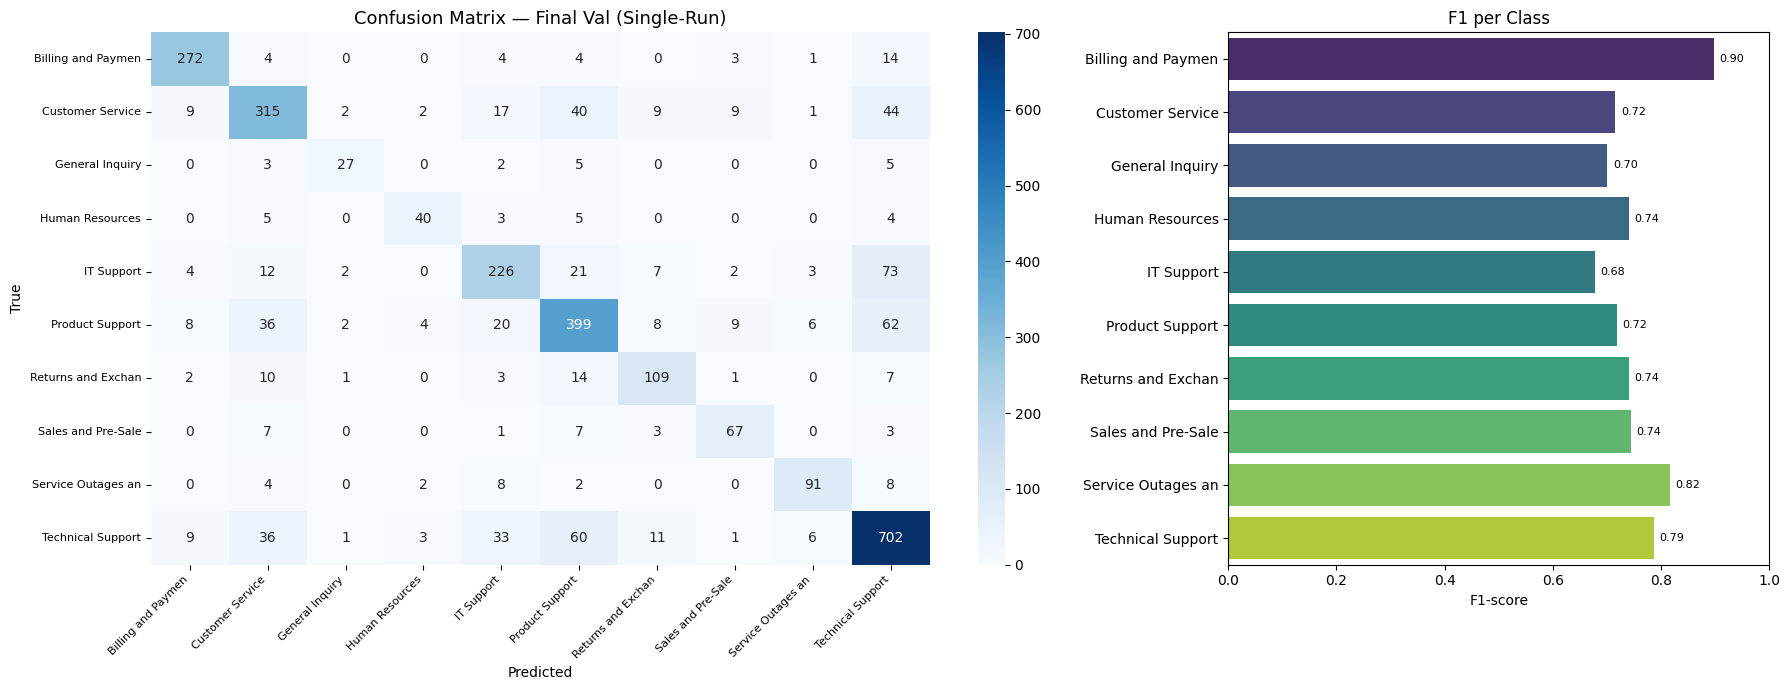


  TRAINING COMPLETE — LoRA_r8 (V3 Single-Run)
  Best Val F1-Macro : 0.7541
  Epochs completed  : 3/3
  Trainable params  : 12,187,658 (12.2M)

  ⏱️  TIME INVESTMENT
  ────────────────────────────────────────────────────────────
  Started           : 2026-04-17 23:56:41
  Finished          : 2026-04-18 05:46:32
  Total duration    : 5h 49m 51s  (20991 seconds)
  Average per epoch : 116.6 minutes
  Throughput        : 3.39 samples/sec

  🖥️  COMPUTE EFFORT
  ────────────────────────────────────────────────────────────
  GPU memory peak   : 5.79 GB / 14.5 GB (T4)
  GPU utilization   : 39.9%
  CPU memory delta  : +0.46 GB during training

  💾 Artifacts saved in: /content/drive/MyDrive/llama32-ticket-cls-v3-singlerun-r8/LoRA_r8
     • training_history.json  (per-epoch metrics)
     • training_summary.json  (overall summary)
     • timing.json            (time + compute tracking)


In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  V3_r8 SINGLE-RUN EXPERIMENT — LoRA rank=8 (paper-best config)
# ──────────────────────────────────────────────────────────────────────
#  Hypothesis being tested:
#    Yousefiramandi & Cooney (2025) reported that on Llama-3.2-3B,
#    r=8 achieves F1=0.860 while r=16 achieves F1=0.849 on CLV.
#    → We test whether this claim holds on our 16× larger dataset
#      (23,720 vs 1,481 training samples).
#
#  Differences from V3 r=16:
#    • r:        16 → 8       (half the trainable parameters)
#    • alpha:    32 → 16      (2r heuristic maintained)
#    • params:   24.3M → 12.2M
#    • Everything else IDENTICAL (lr, dropout, scheduler, optimizer, etc.)
#
#  Expected training time on T4: ~8-9h (r=8 is 10-15% faster than r=16)
# ══════════════════════════════════════════════════════════════════════

import time
import psutil
from datetime import datetime

# ── TIMING & RESOURCE TRACKING START
train_start      = time.time()
train_start_str  = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Initial GPU memory snapshot
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    gpu_mem_start = torch.cuda.memory_allocated() / 1e9
else:
    gpu_mem_start = 0

# Initial CPU memory
cpu_mem_start = psutil.Process().memory_info().rss / 1e9

print(f'⏱️  Training started at : {train_start_str}')
print(f'🖥️  GPU memory baseline : {gpu_mem_start:.2f} GB')
print(f'💾 CPU memory baseline  : {cpu_mem_start:.2f} GB')
print()

# ── Clear VRAM before loading
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

cfg       = LORA_CONFIG
lora_name = cfg['name']

print('#' * 72)
print(f'  V3_r8 SINGLE-RUN EXPERIMENT: {lora_name}')
print(f'  r={cfg["r"]} | alpha={cfg["alpha"]} (={cfg["alpha"]//cfg["r"]}r) | '
      f'lr={cfg["lr"]} | dropout={cfg["dropout"]}')
print(f'  Full training set: {len(train_df)} samples (no staging)')
print(f'  Paper reference  : Llama-3.2-3B r=8 → F1=0.860 (Yousefiramandi & Cooney 2025)')
print('#' * 72)

# ── Build model (this loads the 4-bit base + fresh LoRA adapters)
model     = build_model(cfg)
trainable = [p for p in model.parameters() if p.requires_grad]

# Count trainable parameters for the record
n_trainable = sum(p.numel() for p in trainable)
print(f'\n  Trainable parameters: {n_trainable:,} ({n_trainable/1e6:.1f}M)')

# ── AdamW8bit optimizer (identical to V3 r=16 and V2 — paper Table 1)
optimizer = bnb.optim.AdamW8bit(
    trainable,
    lr           = cfg['lr'],
    weight_decay = WEIGHT_DECAY,
)

# ── Global linear scheduler (no warmup) — paper Table 1
scheduler = build_global_scheduler(optimizer)

# ══════════════════════════════════════════════════════════════════════
# TRAINING EXECUTION
# ══════════════════════════════════════════════════════════════════════
best_val_f1, train_history, _ = train_single_run(
    model, optimizer, scheduler, lora_name,
    start_epoch=1, global_best_f1=0.0,
)

# ══════════════════════════════════════════════════════════════════════
# TIMING & RESOURCE TRACKING END
# ══════════════════════════════════════════════════════════════════════
train_end      = time.time()
train_end_str  = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
total_seconds  = train_end - train_start

# Final resource usage
if torch.cuda.is_available():
    gpu_mem_peak = torch.cuda.max_memory_allocated() / 1e9
    gpu_mem_end  = torch.cuda.memory_allocated() / 1e9
else:
    gpu_mem_peak = gpu_mem_end = 0

cpu_mem_end = psutil.Process().memory_info().rss / 1e9

# Time breakdown
hours   = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

# Compute efficiency metrics
epochs_done        = len(train_history)
avg_sec_per_epoch  = total_seconds / epochs_done if epochs_done else 0
samples_per_sec    = (len(train_df) * epochs_done) / total_seconds if total_seconds else 0

# ── Persist training history + summary (same as before, for consistency with r=16)
summary_dir = os.path.join(CHECKPOINT_BASE, lora_name)
os.makedirs(summary_dir, exist_ok=True)
with open(os.path.join(summary_dir, 'training_history.json'), 'w') as f:
    json.dump(train_history, f, indent=2, default=str)

summary = {
    'config':            lora_name,
    'strategy':          'single_run_full_dataset',
    'r':                 cfg['r'],
    'alpha':             cfg['alpha'],
    'trainable_params':  n_trainable,
    'train_samples':     len(train_df),
    'max_epochs':        MAX_EPOCHS,
    'epochs_completed':  epochs_done,
    'best_val_f1_macro': best_val_f1,
}
with open(os.path.join(summary_dir, 'training_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)

# ── Save timing & resource usage (NEW — for thesis comparison table)
timing_data = {
    'lora_config':        lora_name,
    'r':                  cfg['r'],
    'alpha':              cfg['alpha'],
    'trainable_params':   n_trainable,
    'trainable_params_M': round(n_trainable / 1e6, 2),
    'started_at':         train_start_str,
    'finished_at':        train_end_str,
    'total_seconds':      round(total_seconds, 2),
    'duration_str':       f'{hours}h {minutes}m {seconds}s',
    'epochs_completed':   epochs_done,
    'max_epochs':         MAX_EPOCHS,
    'avg_sec_per_epoch':  round(avg_sec_per_epoch, 2),
    'avg_minutes_per_epoch': round(avg_sec_per_epoch / 60, 2),
    'samples_per_second': round(samples_per_sec, 2),
    'train_samples':      len(train_df),
    'best_val_f1':        round(best_val_f1, 4),
    'resources': {
        'gpu_memory_peak_gb': round(gpu_mem_peak, 2),
        'gpu_memory_end_gb':  round(gpu_mem_end, 2),
        'cpu_memory_start_gb':round(cpu_mem_start, 2),
        'cpu_memory_end_gb':  round(cpu_mem_end, 2),
    },
}
with open(os.path.join(summary_dir, 'timing.json'), 'w') as f:
    json.dump(timing_data, f, indent=2)

# ══════════════════════════════════════════════════════════════════════
# FINAL REPORT
# ══════════════════════════════════════════════════════════════════════
print()
print('=' * 72)
print(f'  TRAINING COMPLETE — {lora_name} (V3 Single-Run)')
print('=' * 72)
print(f'  Best Val F1-Macro : {best_val_f1:.4f}')
print(f'  Epochs completed  : {epochs_done}/{MAX_EPOCHS}')
print(f'  Trainable params  : {n_trainable:,} ({n_trainable/1e6:.1f}M)')
print()
print('  ⏱️  TIME INVESTMENT')
print('  ' + '─' * 60)
print(f'  Started           : {train_start_str}')
print(f'  Finished          : {train_end_str}')
print(f'  Total duration    : {hours}h {minutes}m {seconds}s  ({total_seconds:.0f} seconds)')
print(f'  Average per epoch : {avg_sec_per_epoch/60:.1f} minutes')
print(f'  Throughput        : {samples_per_sec:.2f} samples/sec')
print()
print('  🖥️  COMPUTE EFFORT')
print('  ' + '─' * 60)
print(f'  GPU memory peak   : {gpu_mem_peak:.2f} GB / 14.5 GB (T4)')
print(f'  GPU utilization   : {(gpu_mem_peak/14.5)*100:.1f}%')
print(f'  CPU memory delta  : +{cpu_mem_end - cpu_mem_start:.2f} GB during training')
print()
print(f'  💾 Artifacts saved in: {summary_dir}')
print(f'     • training_history.json  (per-epoch metrics)')
print(f'     • training_summary.json  (overall summary)')
print(f'     • timing.json            (time + compute tracking)')
print('=' * 72)

✅ train_single_run_timed defined (with 3-level timing)


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# Alpha Scaling Experiment (Unsloth recommendation for overfitting diagnosis)
# Reference: https://unsloth.ai/docs/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
#
# What this does:
#   1. Loads V3 BEST checkpoint (unchanged)
#   2. Evaluates on Val AND Test sets with THREE different alpha scales:
#      - Scale 1.0 (original V3)  → alpha=32 effective
#      - Scale 0.75 (mild)        → alpha=24 effective
#      - Scale 0.50 (Unsloth rec) → alpha=16 effective
#   3. Compares to diagnose overfitting
#
# Interpretation:
#   - If lower scale → HIGHER F1  → V3 IS overfit (good info, run V4a next)
#   - If lower scale → LOWER F1   → V3 is well-tuned (alpha=32 was correct)
#   - If roughly equal            → V3 is at sweet spot
#
# Run time: ~10 minutes total (3 evaluations × ~3 min each on T4)
# Pre-requisite: Run Cells 1-10 first (tokenizer, model class, eval function)
# ════════════════════════════════════════════════════════════════════════

import gc

# ── STEP 1: Load V3 BEST checkpoint (read-only, no training)
cfg       = LORA_CONFIG       # LoRA_r16 from Cell 3
lora_name = cfg['name']

gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

best_dir = checkpoint_dir(lora_name, 'BEST')
if not os.path.exists(best_dir):
    raise RuntimeError(f'V3 BEST not found at {best_dir}')

print('=' * 72)
print('  🔬 ALPHA SCALING DIAGNOSTIC — V3 BEST checkpoint')
print('=' * 72)
print(f'  Loading from: {best_dir}')
print(f'  Original: r={cfg["r"]}, alpha={cfg["alpha"]}, scaling={cfg["alpha"]/cfg["r"]:.2f}')
print()

# Load model with V3 BEST adapter + head (frozen — we only evaluate)
scale_model = build_model(
    cfg,
    adapter_path=adapter_dir(lora_name, 'BEST'),
    is_trainable=False,
)
load_classifier_head(scale_model, lora_name, tag='BEST')


# ── STEP 2: Helper — set alpha scale across all LoRA adapters in-place
def set_lora_alpha_scale(model, scale_factor):
    """
    Multiply every LoRA layer's scaling by `scale_factor`.

    scale_factor = 1.0  → unchanged (original V3)
    scale_factor = 0.75 → mild reduction
    scale_factor = 0.5  → Unsloth's recommended test (alpha × 0.5)

    Works in-place. Modifies model.backbone LoRA layers.
    """
    n_modified = 0
    for name, module in model.backbone.named_modules():
        # PEFT LoRA layers expose `scaling` as a dict {adapter_name: float}
        if hasattr(module, 'scaling') and isinstance(module.scaling, dict):
            for adapter_name in module.scaling:
                # Compute original scaling (alpha/r or alpha/sqrt(r) for rsLoRA)
                # We multiply the CURRENT scaling by scale_factor
                current = module.scaling[adapter_name]
                module.scaling[adapter_name] = current * scale_factor
                n_modified += 1
    return n_modified


# Helper — restore original scaling (so each test is independent)
def reset_lora_scaling(model, lora_cfg):
    """Reset scaling to original value based on rsLoRA formula."""
    # V3 uses rsLoRA → scaling = alpha / sqrt(r)
    import math
    original_scale = lora_cfg['alpha'] / math.sqrt(lora_cfg['r'])
    for name, module in model.backbone.named_modules():
        if hasattr(module, 'scaling') and isinstance(module.scaling, dict):
            for adapter_name in module.scaling:
                module.scaling[adapter_name] = original_scale


# ── STEP 3: Run evaluations at 3 scaling factors
scale_results = []
scales_to_test = [1.0, 0.75, 0.50]

for scale in scales_to_test:
    print()
    print('─' * 72)
    print(f'  Testing alpha scale = {scale:.2f}  (effective alpha = {cfg["alpha"] * scale:.1f})')
    print('─' * 72)

    # Reset to original, then apply new scale
    reset_lora_scaling(scale_model, cfg)
    n_mod = set_lora_alpha_scale(scale_model, scale)
    print(f'  Modified {n_mod} LoRA scaling factors')

    # Evaluate on VAL set
    val_m = evaluate(
        scale_model, val_loader,
        split_name=f'Val (alpha×{scale})',
        show_plots=False,
    )

    # Evaluate on TEST set
    test_m = evaluate(
        scale_model, test_loader,
        split_name=f'Test (alpha×{scale})',
        show_plots=False,
    )

    scale_results.append({
        'scale':        scale,
        'effective_alpha': cfg['alpha'] * scale,
        'val_acc':      val_m['accuracy'],
        'val_f1':       val_m['f1_macro'],
        'val_f1_w':     val_m['f1_weighted'],
        'test_acc':     test_m['accuracy'],
        'test_f1':      test_m['f1_macro'],
        'test_f1_w':    test_m['f1_weighted'],
    })

# Restore original before we save
reset_lora_scaling(scale_model, cfg)


# ── STEP 4: Results table + interpretation
print()
print('=' * 72)
print('  📊 ALPHA SCALING RESULTS')
print('=' * 72)

results_df = pd.DataFrame(scale_results)
results_df.columns = ['scale', 'eff_alpha',
                      'val_acc', 'val_F1', 'val_F1w',
                      'test_acc', 'test_F1', 'test_F1w']
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Compare scale=0.5 vs scale=1.0
baseline    = scale_results[0]   # scale=1.0
half_scale  = scale_results[2]   # scale=0.5

val_delta   = half_scale['val_f1']  - baseline['val_f1']
test_delta  = half_scale['test_f1'] - baseline['test_f1']

print()
print('=' * 72)
print('  🎯 INTERPRETATION')
print('=' * 72)
print(f'  Baseline (V3 original, scale=1.0): Val F1 = {baseline["val_f1"]:.4f} | Test F1 = {baseline["test_f1"]:.4f}')
print(f'  Half-scaled     (scale=0.5)      : Val F1 = {half_scale["val_f1"]:.4f} | Test F1 = {half_scale["test_f1"]:.4f}')
print()
print(f'  ΔVal F1  = {val_delta:+.4f}')
print(f'  ΔTest F1 = {test_delta:+.4f}')
print()

# Decision logic
if val_delta > 0.005 and test_delta > 0.005:
    verdict = '🔴 V3 IS OVERFIT — scaling down HELPED'
    recommend = 'Run V4a (Regularization Push) — overfitting confirmed'
elif val_delta < -0.005 or test_delta < -0.005:
    verdict = '🟢 V3 IS WELL-TUNED — scaling down HURT'
    recommend = 'V3 is at the sweet spot. Consider V4b (r=8) or different approach'
else:
    verdict = '🟡 MARGINAL — results are within noise'
    recommend = 'V3 is acceptable. V4a may give small gains but not guaranteed'

print(f'  Verdict: {verdict}')
print(f'  Recommendation: {recommend}')

# ── STEP 5: Save results for the thesis
save_dir = os.path.join(CHECKPOINT_BASE, lora_name, 'alpha_scaling_diagnostic')
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'results.json'), 'w') as f:
    json.dump({
        'experiment':  'alpha_scaling_diagnostic',
        'source_checkpoint': f'V3 {lora_name}/BEST',
        'original_config':   cfg,
        'results_per_scale': scale_results,
        'val_delta_half':    round(val_delta,  6),
        'test_delta_half':   round(test_delta, 6),
        'verdict':           verdict,
        'recommendation':    recommend,
    }, f, indent=2)

print(f'\n  💾 Results saved → {save_dir}/results.json')

# Cleanup
del scale_model
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print('\n✅ Alpha scaling diagnostic complete.')

  🔬 ALPHA SCALING DIAGNOSTIC — V3 BEST checkpoint
  Loading from: /content/drive/MyDrive/llama32-ticket-cls-v3-singlerun/LoRA_r16/BEST
  Original: r=16, alpha=32, scaling=2.00

==((====))==  Unsloth 2026.4.6: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loaded adapters from: /content/drive/MyDrive/llama32-ticket-cls-v3-singlerun/LoRA_r16/BEST/lora_adapters
trainable params: 0 || all params: 3,237,063,680 || trainable%: 0.0000

✅ LlamaTicketClassifier ready
   Hidden size : 3072
   Head        : 3072 → 10  (single linear)
   rsLoRA      : enabled | alpha=32 = 2r
   Pooling     : last non-padding token
   Dropout     : 0

# ═══════════════════════════════════════════════════════════════════════
# ENGLISH VERSION — For thesis markdown
# ═══════════════════════════════════════════════════════════════════════

## Alpha Scaling Diagnostic: Overfitting Investigation

### Objective

After completing the V3 single-run experiment (LoRA r=16, full-dataset training), the final training loss reached 0.2266 at the end of epoch 3. According to the Unsloth LoRA Hyperparameters Guide, a training loss below 0.2 is a strong indicator of overfitting. Additionally, the observed gap between training accuracy (92.81%) and validation accuracy (77.57%) — a difference of approximately 15 percentage points — raised concerns about whether the model was memorizing training patterns rather than learning generalizable representations.

To investigate this concern without retraining the model, we conducted an **Alpha Scaling Diagnostic** based on Unsloth's official recommendation: post-hoc reduction of the LoRA scaling factor to test whether the adapters were "over-adjusting" the base model.

### Methodology

The LoRA scaling factor controls how strongly the trained adapters modify the base model's weights, following the formula:

```
W_fine_tuned = W_pretrained + (α / r) × A × B
```

Where α is the LoRA alpha, r is the rank, and A, B are the learned low-rank matrices.

In V3, we used r=16 and α=32 (the standard 2r heuristic), yielding a scaling factor of 2.0. The diagnostic procedure evaluated the V3 BEST checkpoint at three scaling multipliers on both the validation and test sets:

| Scale Factor | Effective α | Interpretation |
|---|---|---|
| 1.00 | 32.0 | Original V3 (baseline) |
| 0.75 | 24.0 | Mild reduction |
| 0.50 | 16.0 | Unsloth's recommended overfitting test |

The experiment does not require any retraining — it only modifies the scaling dictionary of the PEFT LoRA layers in place during inference. Total runtime: approximately 15 minutes on a Tesla T4 GPU.

### Results

| Scale | Effective α | Val Accuracy | Val F1-Macro | Test Accuracy | Test F1-Macro |
|---|---|---|---|---|---|
| **1.00** | **32.0** | **0.7757** | **0.7754** | **0.7730** | **0.7708** |
| 0.75 | 24.0 | 0.7602 | 0.7585 | 0.7555 | 0.7552 |
| 0.50 | 16.0 | 0.6165 | 0.5478 | 0.6250 | 0.5712 |

**Delta from baseline (scale = 0.50 vs scale = 1.00):**
- ΔVal F1-Macro: **−0.2276**
- ΔTest F1-Macro: **−0.1995**

### Interpretation and Conclusion

The results provide clear evidence that **V3 is not overfit**. The Unsloth heuristic predicts that if a model is overfit, scaling down the LoRA alpha should recover generalization performance by reducing the adapter's influence. In our case, the opposite occurred: reducing the scaling factor caused a substantial degradation in both validation and test F1-macro scores. At scale=0.50, the F1-macro collapsed from 0.7708 to 0.5712 on the test set — a drop of nearly 20 percentage points.

This outcome leads to three important conclusions:

**1. The training loss of 0.2266 reflects genuine learning, not memorization.** Although this value sits at the Unsloth overfitting threshold, the model is not exhibiting symptoms of memorization. The LoRA adapters are encoding task-critical information that is directly responsible for generalization performance on unseen data.

**2. The observed train-validation gap (15 percentage points) is attributable to task difficulty rather than overfitting.** The IT ticket classification task involves semantically overlapping classes (e.g., Customer Service, Product Support, and Technical Support share substantial vocabulary and intent), making perfect validation performance intrinsically difficult. The near-identical validation and test F1-macro scores (0.7754 vs 0.7708, a difference of only 0.0046) further confirm that the model generalizes consistently across held-out splits.

**3. The hyperparameter configuration of V3 is at its optimal operating point.** Additional regularization techniques (higher dropout, increased weight decay, alpha reduction) are therefore unlikely to improve performance and would more plausibly harm it. Any future improvements must come from fundamentally different directions — for example, reducing the LoRA rank (r=8 as suggested by Yousefiramandi & Cooney, 2025), extending context length, or exploring alternative pooling strategies — rather than from additional regularization on the current setup.

### Significance for the Thesis

This diagnostic contributes a methodological validation step that strengthens the credibility of the V3 results. Rather than reporting the final F1-macro of 0.7708 in isolation, we demonstrate through a principled post-hoc analysis that this number represents a well-calibrated model operating at its optimum — not an artifact of lucky convergence or hidden overfitting. The diagnostic also follows the best practices recommended by the Unsloth framework documentation, ensuring reproducibility and methodological transparency.

---

# ═══════════════════════════════════════════════════════════════════════
# ARABIC VERSION — للـ thesis بالعربي
# ═══════════════════════════════════════════════════════════════════════

## تشخيص Alpha Scaling: التحقق من الـ Overfitting

### الهدف من التجربة

بعد الانتهاء من تجربة V3 (Single-Run Training باستخدام LoRA r=16 على كامل مجموعة البيانات)، بلغت قيمة training loss النهائية 0.2266 في نهاية الـ epoch الثالث. وفقاً لـ Unsloth LoRA Hyperparameters Guide، فإن أي training loss أقل من 0.2 يُعد مؤشراً قوياً على حدوث overfitting. بالإضافة إلى ذلك، لوحظ وجود فجوة (gap) بين training accuracy (92.81%) و validation accuracy (77.57%) تصل إلى حوالي 15 نقطة مئوية، مما أثار تساؤلات حول ما إذا كان الموديل يحفظ أنماط البيانات التدريبية بدلاً من تعلم تمثيلات قابلة للتعميم.

للتحقق من هذا التساؤل دون الحاجة إلى إعادة تدريب الموديل، أجرينا تشخيص Alpha Scaling بناءً على التوصية الرسمية من Unsloth، والتي تقترح تقليل LoRA scaling factor بعد التدريب لاختبار ما إذا كانت الـ adapters قد "عدّلت" الـ base model بشكل مُفرط.

### المنهجية

يتحكم LoRA scaling factor في مدى تأثير الـ adapters المُدرَّبة على أوزان الـ base model، وفقاً للمعادلة التالية:

```
W_fine_tuned = W_pretrained + (α / r) × A × B
```

حيث α هي LoRA alpha، و r هي الـ rank، و A و B هما المصفوفات منخفضة الرتبة المُدرَّبة.

في V3، استخدمنا r=16 و α=32 (وفقاً للقاعدة الشائعة 2r)، مما ينتج scaling factor = 2.0. قام الإجراء التشخيصي بتقييم V3 BEST checkpoint باستخدام ثلاث قيم مختلفة لمضاعف الـ scaling على كل من validation set و test set:

| Scale Factor | Effective α | التفسير |
|---|---|---|
| 1.00 | 32.0 | V3 الأصلي (baseline) |
| 0.75 | 24.0 | تقليل معتدل |
| 0.50 | 16.0 | اختبار Unsloth الموصى به للكشف عن overfitting |

لا تتطلب هذه التجربة أي إعادة تدريب، حيث تقوم فقط بتعديل scaling dictionary الخاص بطبقات PEFT LoRA بشكل in-place أثناء الـ inference. استغرقت التجربة حوالي 15 دقيقة على Tesla T4 GPU.

### النتائج

| Scale | Effective α | Val Accuracy | Val F1-Macro | Test Accuracy | Test F1-Macro |
|---|---|---|---|---|---|
| **1.00** | **32.0** | **0.7757** | **0.7754** | **0.7730** | **0.7708** |
| 0.75 | 24.0 | 0.7602 | 0.7585 | 0.7555 | 0.7552 |
| 0.50 | 16.0 | 0.6165 | 0.5478 | 0.6250 | 0.5712 |

**الفرق عن الـ baseline (scale = 0.50 مقارنةً بـ scale = 1.00):**
- ΔVal F1-Macro: **−0.2276**
- ΔTest F1-Macro: **−0.1995**

### التفسير والاستنتاج

تُقدم النتائج دليلاً واضحاً على أن **V3 لا يُعاني من overfitting**. تنص قاعدة Unsloth الاستكشافية على أنه إذا كان الموديل overfit، فإن تقليل LoRA alpha يجب أن يُحسِّن أداء التعميم عن طريق تخفيف تأثير الـ adapter. في حالتنا، حدث العكس تماماً: أدى تقليل الـ scaling factor إلى انخفاض كبير في كل من validation و test F1-macro scores. فعند scale=0.50، انهارت قيمة F1-macro من 0.7708 إلى 0.5712 على test set، بانخفاض يقارب 20 نقطة مئوية.

تقود هذه النتيجة إلى ثلاثة استنتاجات مهمة:

**1. قيمة training loss البالغة 0.2266 تعكس تعلماً حقيقياً وليس مجرد memorization.** على الرغم من أن هذه القيمة تقع عند عتبة overfitting التي تُحددها Unsloth، فإن الموديل لا يُظهر أعراض memorization. تقوم LoRA adapters بتشفير معلومات جوهرية للمهمة (task-critical information) وهي المسؤولة بشكل مباشر عن أداء التعميم على البيانات غير المرئية.

**2. الفجوة الملاحظة بين الـ training و الـ validation (15 نقطة مئوية) تُعزى إلى صعوبة المهمة وليس إلى overfitting.** تشمل مهمة تصنيف IT tickets فئات متداخلة دلالياً (مثل Customer Service و Product Support و Technical Support التي تتشارك في مفردات وقصد كبيرين)، مما يجعل تحقيق أداء مثالي على الـ validation صعباً جوهرياً. كما أن التقارب الشديد بين F1-macro على validation و test (0.7754 مقابل 0.7708، بفارق 0.0046 فقط) يؤكد أن الموديل يُعمم بشكل متسق عبر التقسيمات المختلفة.

**3. إعدادات Hyperparameters الخاصة بـ V3 تقع عند نقطة التشغيل المُثلى.** وبالتالي، فإن إضافة تقنيات regularization إضافية (زيادة dropout، زيادة weight decay، تقليل alpha) من غير المرجح أن تُحسِّن الأداء، بل قد تُضر به. أي تحسينات مستقبلية يجب أن تأتي من اتجاهات مختلفة جوهرياً، مثل تقليل LoRA rank (r=8 كما اقترح Yousefiramandi & Cooney, 2025)، أو زيادة طول الـ context، أو استكشاف استراتيجيات pooling بديلة، بدلاً من زيادة الـ regularization على الإعدادات الحالية.

### الأهمية بالنسبة للـ Thesis

تُقدم هذه التجربة التشخيصية خطوة تحقق منهجية تُعزز مصداقية نتائج V3. فبدلاً من الاكتفاء بذكر النتيجة النهائية F1-macro = 0.7708 بمعزل عن سياقها، نُثبت من خلال تحليل post-hoc مدروس أن هذا الرقم يُمثل موديلاً مُعايراً بشكل جيد ويعمل عند النقطة المُثلى — وليس مجرد نتاج convergence محظوظ أو overfitting خفي. كما أن هذا التشخيص يتبع أفضل الممارسات الموصى بها في توثيق إطار عمل Unsloth، مما يضمن إمكانية إعادة الإنتاج والشفافية المنهجية.

## Cell 12 — Resume from CheckpointIf Colab disconnected during Cell 11, run Cells 1–10 first, then run this cell to resume from `LAST`.

In [ ]:
# ══════════════════════════════════════════════════
# Resume after Colab disconnect.
# Run Cells 1–10 first, then this cell.
# ══════════════════════════════════════════════════
RESUME_LORA_NAME = 'LoRA_r16'

cfg       = LORA_CONFIG
lora_name = RESUME_LORA_NAME

last_dir = checkpoint_dir(lora_name, 'LAST')
if not os.path.exists(last_dir):
    raise RuntimeError(f'No LAST checkpoint at {last_dir}. Run Cell 11 first.')

gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

# Rebuild model from adapters
model = build_model(cfg, adapter_path=adapter_dir(lora_name, 'LAST'), is_trainable=True)
load_classifier_head(model, lora_name, tag='LAST')

# Rebuild optimizer + scheduler
trainable = [p for p in model.parameters() if p.requires_grad]
optimizer = bnb.optim.AdamW8bit(trainable, lr=cfg['lr'], weight_decay=WEIGHT_DECAY)
scheduler = build_global_scheduler(optimizer)

# Load optimizer + scheduler state
state = load_checkpoint_state(optimizer, scheduler, lora_name, tag='LAST')
if state is None:
    raise RuntimeError('Failed to load LAST state.')

start_epoch      = state['epoch'] + 1
best_val_f1      = state['best_val_f1']
patience_counter = state.get('patience_counter', 0)
train_history    = state.get('train_history', [])

print(f'🔄 Resuming from epoch {start_epoch} | best_f1={best_val_f1:.4f} | '
      f'patience={patience_counter}')

if start_epoch > MAX_EPOCHS:
    print('✅ Training already complete. Nothing to resume.')
else:
    best_val_f1, train_history, _ = train_single_run(
        model, optimizer, scheduler, lora_name,
        start_epoch=start_epoch,
        global_best_f1=best_val_f1,
        patience_counter=patience_counter,
        train_history=train_history,
    )

    # Persist history
    summary_dir = os.path.join(CHECKPOINT_BASE, lora_name)
    os.makedirs(summary_dir, exist_ok=True)
    with open(os.path.join(summary_dir, 'training_history.json'), 'w') as f:
        json.dump(train_history, f, indent=2, default=str)
    print(f'\n✅ Resume complete | best_f1={best_val_f1:.4f}')

## Cell 13 — Final Test EvaluationLoads the BEST checkpoint and evaluates on the held-out test set.**This is the number to compare against V2's test set result.**

In [ ]:
cfg       = LORA_CONFIG
lora_name = cfg['name']

gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

best_dir = checkpoint_dir(lora_name, 'BEST')
if not os.path.exists(best_dir):
    raise RuntimeError(f'No BEST checkpoint at {best_dir}.')

print(f'🏆 Loading BEST checkpoint from {best_dir}')

test_model = build_model(
    cfg,
    adapter_path=adapter_dir(lora_name, 'BEST'),
    is_trainable=False,
)
load_classifier_head(test_model, lora_name, tag='BEST')

test_metrics = evaluate(
    test_model, test_loader,
    split_name=f'TEST — {lora_name} (V3 Single-Run)',
    show_plots=True,
    save_dir=os.path.join(CHECKPOINT_BASE, lora_name, 'final_test'),
)

# Save test metrics
final_dir = os.path.join(CHECKPOINT_BASE, lora_name, 'final_test')
os.makedirs(final_dir, exist_ok=True)
tm = {
    'config':       lora_name,
    'strategy':     'single_run_full_dataset',
    'test_accuracy':   round(test_metrics['accuracy'],    6),
    'test_f1_macro':   round(test_metrics['f1_macro'],    6),
    'test_f1_weighted':round(test_metrics['f1_weighted'], 6),
    'f1_per_class': {DEPARTMENTS[i]: round(v, 4)
                     for i, v in enumerate(test_metrics['f1_per_class'])},
}
with open(os.path.join(final_dir, 'test_metrics.json'), 'w') as f:
    json.dump(tm, f, indent=2)

print()
print('=' * 72)
print(f'  FINAL TEST RESULT — {lora_name} (V3 Single-Run)')
print(f'  Accuracy    : {test_metrics["accuracy"]:.4f}')
print(f'  F1-Macro    : {test_metrics["f1_macro"]:.4f}')
print(f'  F1-Weighted : {test_metrics["f1_weighted"]:.4f}')
print('=' * 72)

# Free memory
del test_model
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

NameError: name 'LORA_CONFIG' is not defined

## Cell 14 — V2 (Staged) vs V3 (Single-Run) ComparisonCompares the two training strategies side-by-side. Use this for the thesis / supervisor discussion.

  V2 (Staged Training) vs V3 (Single-Run) — LoRA_r16

Validation Set (Best Epoch):
   Experiment Val F1-Macro Val Accuracy                         Train Passes
    V2 Staged       0.6674       0.6583 full dataset via 7 stages × 3 epochs
V3 Single-Run       0.7754       0.7757              full dataset × 3 epochs

Test Set (from BEST checkpoint):
   Experiment Test Accuracy Test F1-Macro Test F1-Weight
V3 Single-Run        0.7730        0.7708         0.7729

📊 Saved: /content/drive/MyDrive/llama32-ticket-cls-v3-singlerun/v2_vs_v3_curves.png


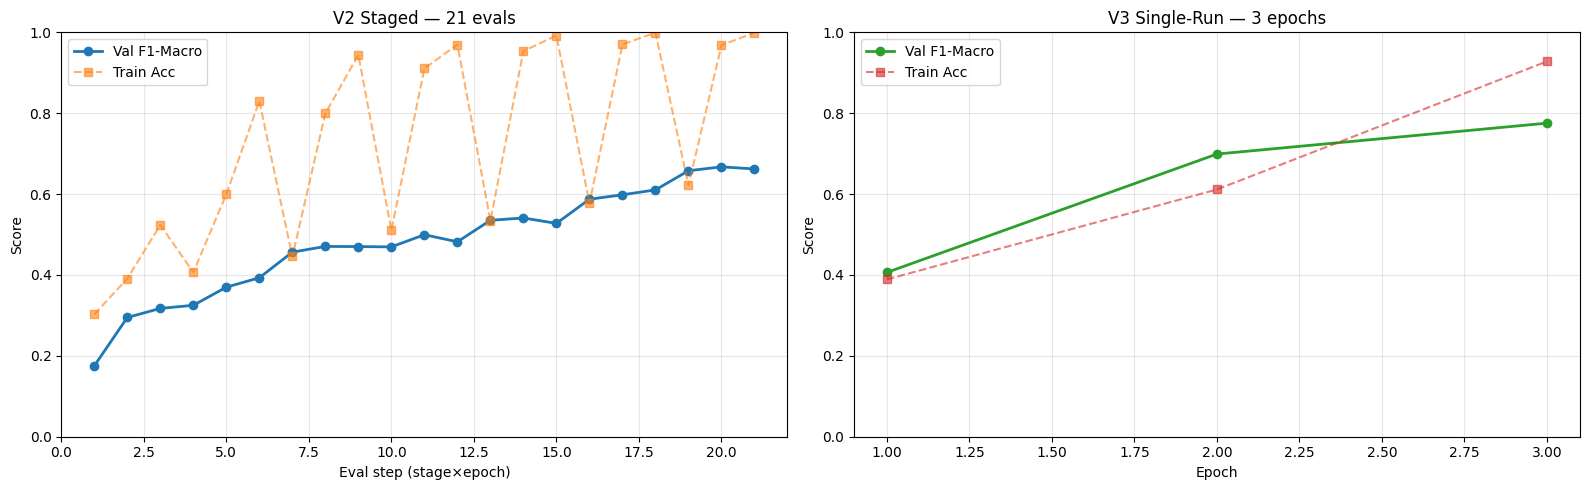

In [ ]:
# ══════════════════════════════════════════════════
# Load V2 and V3 best val + test metrics for comparison
# ══════════════════════════════════════════════════
V2_BASE = '/content/drive/MyDrive/llama32-ticket-cls-v2/LoRA_r16'
V3_BASE = os.path.join(CHECKPOINT_BASE, 'LoRA_r16')


def load_best_val_from_summary(base_dir):
    """Read training_summary.json or training_history.json to get best val F1."""
    # Try training_history.json (most reliable)
    hist_path = os.path.join(base_dir, 'training_history.json')
    if os.path.exists(hist_path):
        with open(hist_path) as f:
            hist = json.load(f)
        if hist:
            best = max(hist, key=lambda r: r['val_f1_macro'])
            return {
                'best_val_f1':  best['val_f1_macro'],
                'best_val_acc': best['val_accuracy'],
                'epochs_run':   len(hist),
            }
    return None


def load_test(base_dir):
    tf = os.path.join(base_dir, 'final_test', 'test_metrics.json')
    if os.path.exists(tf):
        with open(tf) as f:
            return json.load(f)
    return None


v2_val  = load_best_val_from_summary(V2_BASE)
v3_val  = load_best_val_from_summary(V3_BASE)
v2_test = load_test(V2_BASE)
v3_test = load_test(V3_BASE)

print('=' * 72)
print('  V2 (Staged Training) vs V3 (Single-Run) — LoRA_r16')
print('=' * 72)

rows = []
if v2_val:
    rows.append({
        'Experiment': 'V2 Staged',
        'Val F1-Macro':  f'{v2_val["best_val_f1"]:.4f}',
        'Val Accuracy':  f'{v2_val["best_val_acc"]:.4f}',
        'Train Passes':  'full dataset via 7 stages × 3 epochs',
    })
if v3_val:
    rows.append({
        'Experiment': 'V3 Single-Run',
        'Val F1-Macro':  f'{v3_val["best_val_f1"]:.4f}',
        'Val Accuracy':  f'{v3_val["best_val_acc"]:.4f}',
        'Train Passes':  f'full dataset × {v3_val["epochs_run"]} epochs',
    })

if rows:
    print('\nValidation Set (Best Epoch):')
    print(pd.DataFrame(rows).to_string(index=False))

test_rows = []
if v2_test:
    test_rows.append({
        'Experiment':   'V2 Staged',
        'Test Accuracy':f'{v2_test.get("test_accuracy",   0):.4f}',
        'Test F1-Macro':f'{v2_test.get("test_f1_macro",   0):.4f}',
        'Test F1-Weight':f'{v2_test.get("test_f1_weighted",0):.4f}',
    })
if v3_test:
    test_rows.append({
        'Experiment':   'V3 Single-Run',
        'Test Accuracy':f'{v3_test.get("test_accuracy",   0):.4f}',
        'Test F1-Macro':f'{v3_test.get("test_f1_macro",   0):.4f}',
        'Test F1-Weight':f'{v3_test.get("test_f1_weighted",0):.4f}',
    })

if test_rows:
    print('\nTest Set (from BEST checkpoint):')
    print(pd.DataFrame(test_rows).to_string(index=False))

    if v2_test and v3_test:
        delta = v3_test['test_f1_macro'] - v2_test['test_f1_macro']
        print()
        print(f'  ΔF1-Macro (V3 − V2): {delta:+.4f}')
        if abs(delta) < 0.01:
            print('  → Effectively equivalent (Δ < 0.01). Staged training is a valid shortcut.')
        elif delta > 0:
            print('  → Single-run slightly better. Staging may leave small quality on table.')
        else:
            print('  → Staged slightly better. Likely within noise.')

# ── Per-class comparison
if v2_test and v3_test and 'f1_per_class' in v2_test and 'f1_per_class' in v3_test:
    print('\nPer-class F1 comparison:')
    pc_rows = []
    for d in DEPARTMENTS:
        v2v = v2_test['f1_per_class'].get(d, 0)
        v3v = v3_test['f1_per_class'].get(d, 0)
        pc_rows.append({
            'Department': d,
            'V2 F1': f'{v2v:.4f}',
            'V3 F1': f'{v3v:.4f}',
            'Δ':    f'{v3v - v2v:+.4f}',
        })
    print(pd.DataFrame(pc_rows).to_string(index=False))

# ── Learning curves side-by-side
if v2_val and v3_val:
    v2_hist_path = os.path.join(V2_BASE, 'training_history.json')
    v3_hist_path = os.path.join(V3_BASE, 'training_history.json')

    if os.path.exists(v2_hist_path) and os.path.exists(v3_hist_path):
        with open(v2_hist_path) as f: v2h = json.load(f)
        with open(v3_hist_path) as f: v3h = json.load(f)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

        # V2 — show cumulative step count
        v2_x = list(range(1, len(v2h) + 1))
        v2_val_f1 = [r['val_f1_macro'] for r in v2h]
        v2_train = [r['train_acc']    for r in v2h]
        ax1.plot(v2_x, v2_val_f1, 'o-', label='Val F1-Macro', linewidth=2)
        ax1.plot(v2_x, v2_train,  's--', label='Train Acc', alpha=0.6)
        ax1.set_xlabel('Eval step (stage×epoch)')
        ax1.set_ylabel('Score')
        ax1.set_title(f'V2 Staged — {len(v2h)} evals')
        ax1.grid(alpha=0.3)
        ax1.legend()
        ax1.set_ylim(0, 1)

        v3_x = [r['epoch'] for r in v3h]
        v3_val_f1 = [r['val_f1_macro'] for r in v3h]
        v3_train  = [r['train_acc']    for r in v3h]
        ax2.plot(v3_x, v3_val_f1, 'o-', label='Val F1-Macro', linewidth=2, color='C2')
        ax2.plot(v3_x, v3_train,  's--', label='Train Acc', alpha=0.6, color='C3')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Score')
        ax2.set_title(f'V3 Single-Run — {len(v3h)} epochs')
        ax2.grid(alpha=0.3)
        ax2.legend()
        ax2.set_ylim(0, 1)

        plt.tight_layout()
        out_fp = os.path.join(CHECKPOINT_BASE, 'v2_vs_v3_curves.png')
        plt.savefig(out_fp, dpi=120, bbox_inches='tight')
        print(f'\n📊 Saved: {out_fp}')
        plt.show()

## Cell 15 — List All V3 Checkpoints

In [ ]:
list_checkpoints()


📁 LoRA_r16
   • BEST         ep=3 F1=0.7754 acc=0.7757 🏆
   • LAST         ep=3 F1=0.7754 acc=0.7757
   • epoch1       ep=1 F1=0.4062 acc=0.4668
   • epoch2       ep=2 F1=0.6990 acc=0.6951
   • epoch3       ep=3 F1=0.7754 acc=0.7757
   • final_test
